Completion and Compliance
====

Metrics and stats for completion and compliance rates

In [1]:
import os

%load_ext autoreload
%autoreload 2

img_dir = "outputs/imgs/quantitative/"
if not os.path.exists(img_dir):
    os.makedirs(img_dir)

In [2]:
"""
Read the data

"""

from analysis_utils import clean

meal_info = clean.cleaned_smartwatch(keep_catchups=False, keep_day0=False)
meal_info.head()

/home/mh19137/seaco_smartwatch_paper/analysis_utils/clean.py:156: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Normal' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  copy.loc[start_time, col_name] = "Normal"
/home/mh19137/seaco_smartwatch_paper/analysis_utils/clean.py:227: UserWarning: Long catchup: not marking Meal at 2022-05-19 09:02:49 as catchup
  warnings.warn(


 Open ended catchup at 2022-02-11 20:02:05 ended by No response at 2022-02-12 08:02:11
 Open ended catchup at 2022-02-14 20:26:30 ended by No response at 2022-02-15 08:02:16
 Open ended catchup at 2022-04-19 08:01:14 ended by No catch-up at 2022-04-19 08:01:17
 Open ended catchup at 2022-06-27 15:53:14 ended by Catch-up start at 2022-06-27 15:54:06
 Open ended catchup at 2021-12-31 22:11:10 ended by No catch-up at 2022-01-01 08:01:15
 Open ended catchup at 2022-05-24 07:25:36 ended by Catch-up start at 2022-05-24 07:26:00
 Open ended catchup at 2022-03-21 08:01:57 ended by No catch-up at 2022-03-21 08:02:04
 Open ended catchup at 2022-03-07 18:33:30 ended by No catch-up at 2022-03-07 18:33:34
 Open ended catchup at 2022-03-07 18:37:08 ended by No catch-up at 2022-03-07 18:37:14
 Open ended catchup at 2022-03-07 19:29:23 ended by No response at 2022-03-08 08:02:56
 Open ended catchup at 2022-03-08 08:30:40 ended by No catch-up at 2022-03-08 08:31:08
 Open ended catchup at 2022-03-08 09:

,x_id,meal_type,portion_size,utensil,location,week_day,p_id,ramadanstart,ramadanend,delta,catchup_category,catchup_flag,entry_in_ramadan,early_stop,first_in_ramadan,last_in_ramadan,all_in_ramadan,any_in_ramadan
Datetime,,,,,,,,,,,,,,,,,,
2021-11-03 09:00:43,17,Meal,Large,Fork/spoon,Home,Wednesday,16231,03apr2022,01may2022,1 days 09:00:43,NaN,False,False,False,False,False,False,False
2021-11-03 09:00:49,18,Drink,Large,No response,Home,Wednesday,16231,03apr2022,01may2022,1 days 09:00:49,NaN,False,False,False,False,False,False,False
2021-11-03 10:01:03,19,Meal,Large,Fork/spoon,Home,Wednesday,16231,03apr2022,01may2022,1 days 10:01:03,NaN,False,False,False,False,False,False,False
2021-11-03 11:01:07,20,No food/drink,No response,No response,No response,Wednesday,16231,03apr2022,01may2022,1 days 11:01:07,NaN,False,False,False,False,False,False,False
2021-11-03 12:01:16,21,Drink,Mid-size,No response,Home,Wednesday,16231,03apr2022,01may2022,1 days 12:01:16,NaN,False,False,False,False,False,False,False


In [7]:
"""
Collapse entries into a bool

"""
meal_info["entry"] = meal_info["meal_type"].isin(
    {"Meal", "Drink", "Snack", "No food/drink"}
)

In [8]:
"""
Define a cutoff for meal length

"""
import numpy as np
import pandas as pd


# Find the average and maximum number of entries per participant
def collapse_meal_info(meal_df: pd.DataFrame, delta: pd.Timedelta) -> pd.DataFrame:
    collapsed_meal_info = pd.DataFrame()

    for p_id, group in meal_df.groupby("p_id"):
        assert group.index.is_monotonic_increasing

        # Mark which ones are near enough each other to be considered the same
        n_entries = len(group)
        keep = np.ones(n_entries, dtype=bool)

        for i in range(1, n_entries):
            if (group.index[i] - group.index[i - 1] < delta) and (
                group["entry"].iloc[i] == group["entry"].iloc[i - 1]
            ):
                keep[i] = False

        # Append to the new dataframe
        collapsed_meal_info = pd.concat([collapsed_meal_info, group[keep]])

    return collapsed_meal_info

In [31]:
deltas = pd.timedelta_range(start="1min", end="60min", freq="1min")

collapsed_meal_infos = [collapse_meal_info(meal_info, delta) for delta in deltas]

# Number of entries per participant per day
avg_entries_per_day = [
    len(collapsed_meal_info) / (7 * meal_info["p_id"].unique().size)
    for collapsed_meal_info in collapsed_meal_infos
]

# Maximum entries
max_entries_per_day = []
for collapsed_meal_info in collapsed_meal_infos:
    collapsed_meal_info["date"] = collapsed_meal_info.index.date

    max_entries_per_day.append(
        collapsed_meal_info.groupby(["p_id", "date"]).size().max()
    )

In [ ]:
time_cutoff_min = 27

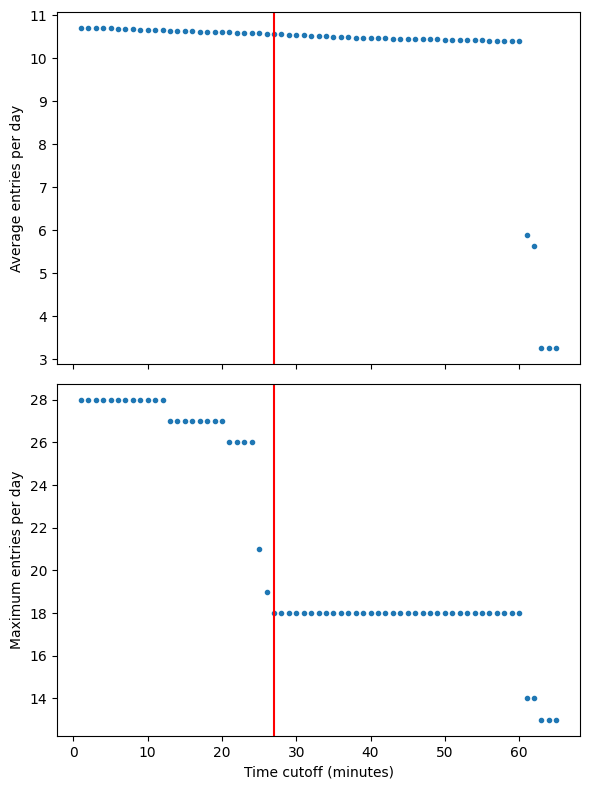

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

axes[0].plot(deltas.total_seconds() / 60, avg_entries_per_day, ".")
axes[1].plot(deltas.total_seconds() / 60, max_entries_per_day, ".")

axes[0].set_ylabel("Average entries per day")
axes[1].set_ylabel("Maximum entries per day")

axes[1].set_xlabel("Time cutoff (minutes)")

for axis in axes:
    axis.axvline(time_cutoff_min, color="r")

fig.tight_layout()

In [ ]:
compliance_df = collapse_meal_info(meal_info, pd.Timedelta(minutes=time_cutoff_min))
compliance_df.head()

,x_id,meal_type,portion_size,utensil,location,week_day,p_id,ramadanstart,ramadanend,delta,catchup_category,catchup_flag,entry_in_ramadan,early_stop,first_in_ramadan,last_in_ramadan,all_in_ramadan,any_in_ramadan,entry
Datetime,,,,,,,,,,,,,,,,,,,
2022-04-09 08:02:16,306,No response,No response,No response,No response,Saturday,141,03apr2022,01may2022,1 days 08:02:16,NaN,False,True,False,True,True,True,True,False
2022-04-09 09:02:24,307,No food/drink,No response,No response,No response,Saturday,141,03apr2022,01may2022,1 days 09:02:24,NaN,False,True,False,True,True,True,True,True
2022-04-09 10:04:24,308,No response,No response,No response,No response,Saturday,141,03apr2022,01may2022,1 days 10:04:24,NaN,False,True,False,True,True,True,True,False
2022-04-09 11:04:28,309,No food/drink,No response,No response,No response,Saturday,141,03apr2022,01may2022,1 days 11:04:28,NaN,False,True,False,True,True,True,True,True
2022-04-09 12:04:32,310,No food/drink,No response,No response,No response,Saturday,141,03apr2022,01may2022,1 days 12:04:32,NaN,False,True,False,True,True,True,True,True


In [ ]:
"""
Compliance rate for all participants

"""
# Compare how many entries there were per day to the number we expect
# Find an average
# Plot

In [1]:
"""
Compliance rate for active participants

"""
# Find active participants
# Find their compliance rate, same as the above

'\nCompliance rate for active participants\n\n'

In [ ]:
"""
Completion rate

"""
# Find the completion rate per day
# Find an average
# Plot